In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
debashishsau_aslamerican_sign_language_aplhabet_dataset_path = kagglehub.dataset_download('debashishsau/aslamerican-sign-language-aplhabet-dataset')

print('Data source import complete.')

100%|██████████| 4.20G/4.20G [04:01<00:00, 18.7MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os

print(debashishsau_aslamerican_sign_language_aplhabet_dataset_path)
os.listdir(debashishsau_aslamerican_sign_language_aplhabet_dataset_path)

/root/.cache/kagglehub/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/versions/1


['ASL_Alphabet_Dataset']

In [ ]:
import cv2
import numpy as np
from tqdm import tqdm
IMG_SIZE = 64

hog = cv2.HOGDescriptor(
    _winSize=(64, 64),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

In [ ]:
import os

base_path = debashishsau_aslamerican_sign_language_aplhabet_dataset_path
dataset_root = os.path.join(base_path, "ASL_Alphabet_Dataset")

print("Dataset root contents:", os.listdir(dataset_root))

Dataset root contents: ['asl_alphabet_test', 'asl_alphabet_train']


In [ ]:
import os

base_path = debashishsau_aslamerican_sign_language_aplhabet_dataset_path
dataset_root = os.path.join(base_path, "ASL_Alphabet_Dataset")
train_dir = os.path.join(dataset_root, "asl_alphabet_train")

print("Train dir exists:", os.path.exists(train_dir))

Train dir exists: True


In [ ]:
classes = sorted(os.listdir(train_dir))
print("Total number of classes:", len(classes))
print(classes)

Total number of classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm
import os

IMG_SIZE = 64

hog = cv2.HOGDescriptor(
    _winSize=(64, 64),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

X, y = [], []

classes = sorted(os.listdir(train_dir))

for label, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in tqdm(os.listdir(class_path), desc=class_name):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        features = hog.compute(img)

        X.append(features.flatten())
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

space: 100%|██████████| 7071/7071 [00:08<00:00, 880.43it/s] 


X shape: (223074, 1764)
y shape: (223074,)


In [ ]:
np.save("X_hog.npy", X)
np.save("y.npy", y)
np.save("classes.npy", classes)

In [ ]:
X = np.load("X_hog.npy")
y = np.load("y.npy")
classes = np.load("classes.npy", allow_pickle=True)

In [ ]:
from collections import defaultdict

limit = 700   # per class
counter = defaultdict(int)

X_small, y_small = [], []

for xi, yi in zip(X, y):
    if counter[yi] < limit:
        X_small.append(xi)
        y_small.append(yi)
        counter[yi] += 1

X_small = np.array(X_small)
y_small = np.array(y_small)

print("Reduced shape:", X_small.shape)

Reduced shape: (20300, 1764)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=120, random_state=42)
X_pca = pca.fit_transform(X_small)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_small, test_size=0.2, random_state=42
)

svm = LinearSVC(C=1.0, max_iter=6000)
svm.fit(X_train, y_train)

LinearSVC(max_iter=6000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

report = classification_report(
    y_test, y_pred,
    target_names=classes,
    output_dict=True
)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5795566502463054


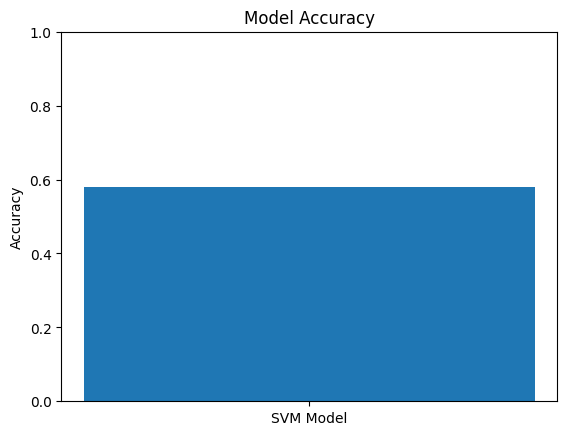

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

plt.bar(["SVM Model"], [accuracy])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.show()

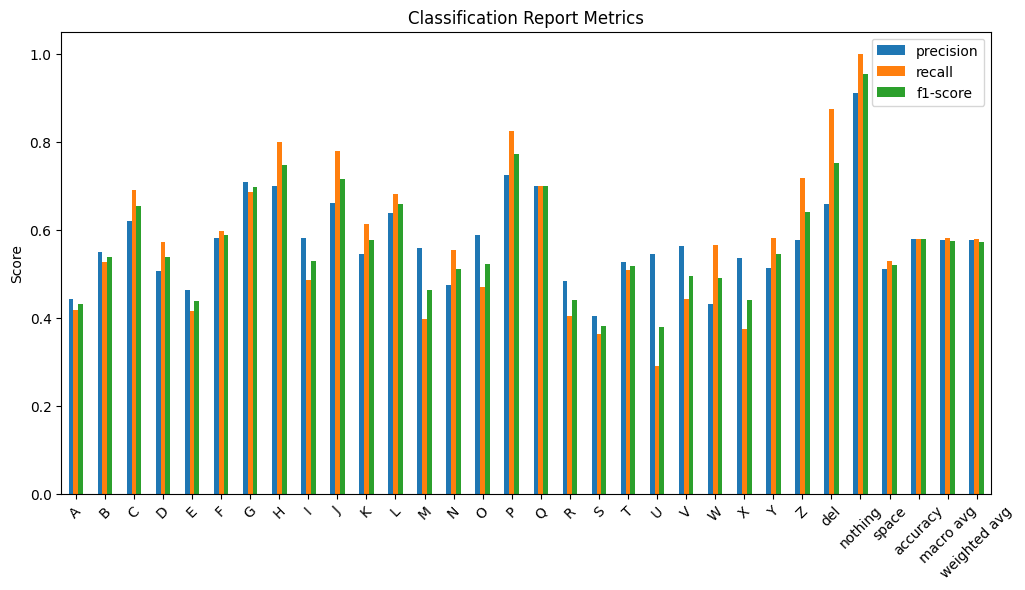

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
df = pd.DataFrame(report).transpose()

df[['precision','recall','f1-score']].plot(kind='bar', figsize=(12,6))
plt.title("Classification Report Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import json

results = {
    "model_name": "SVM_HOG_PCA",
    "accuracy": accuracy,
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
    "f1_score": report["macro avg"]["f1-score"]
}

In [ ]:
import numpy as np

# Save metrics
with open("svm_results.json", "w") as f:
    json.dump(results, f)

# Save confusion matrix
np.save("svm_confusion_matrix.npy", cm)

# Save class labels
np.save("svm_classes.npy", classes)

In [ ]:
def predict_asl(image_path):
    import cv2
    import numpy as np

    img = cv2.imread("test1.jpeg", cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("❌ Image could not be read")
        return

    img = cv2.resize(img, (64, 64))
    features = hog.compute(img).flatten()
    features_pca = pca.transform([features])
    pred = svm.predict(features_pca)[0]

    print("✅ Predicted Sign:", classes[pred])

predict_asl(img_path)

✅ Predicted Sign: A


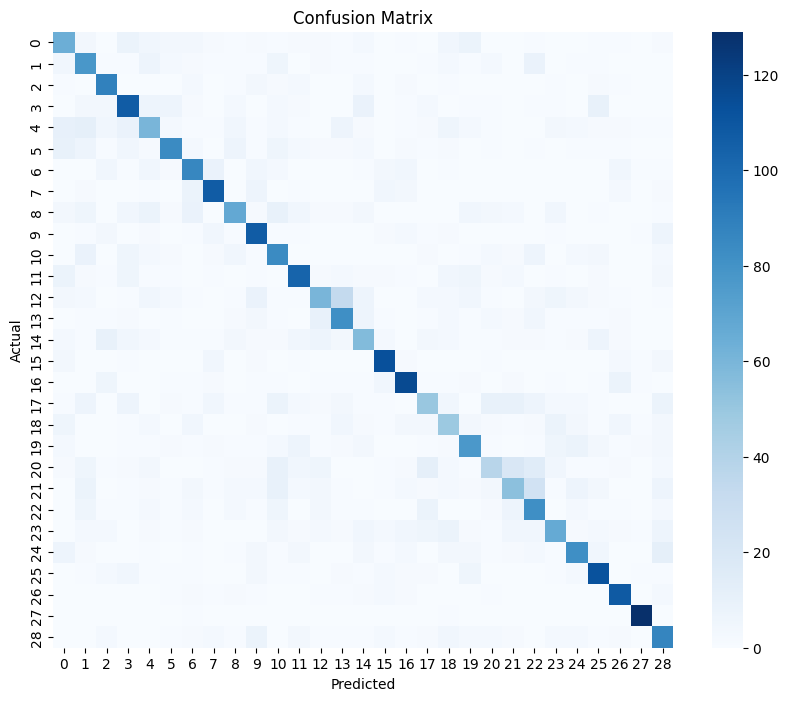

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def predict_word_with_repeats(image_repeat_list):
    letters = []

    for img_name, repeat in image_repeat_list:
        img = cv2.imread(img_name, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (64, 64))
        features = hog.compute(img).flatten()
        features_pca = pca.transform([features])

        pred = svm.predict(features_pca)[0]
        letter = classes[pred]

        for _ in range(repeat):
            if letter == "space":
                letters.append(" ")
            elif letter == "del":
                if letters:
                    letters.pop()
            elif letter == "nothing":
                continue
            else:
                letters.append(letter)

    return "".join(letters)

In [ ]:
word = predict_word_with_repeats([
    ("test1.jpeg", 1),
    ("test2.jpeg", 2),
    ("test3.jpeg", 1),
    ("test4.jpeg", 1)
])

print("Predicted Word:", word)

Predicted Word: APPLE
